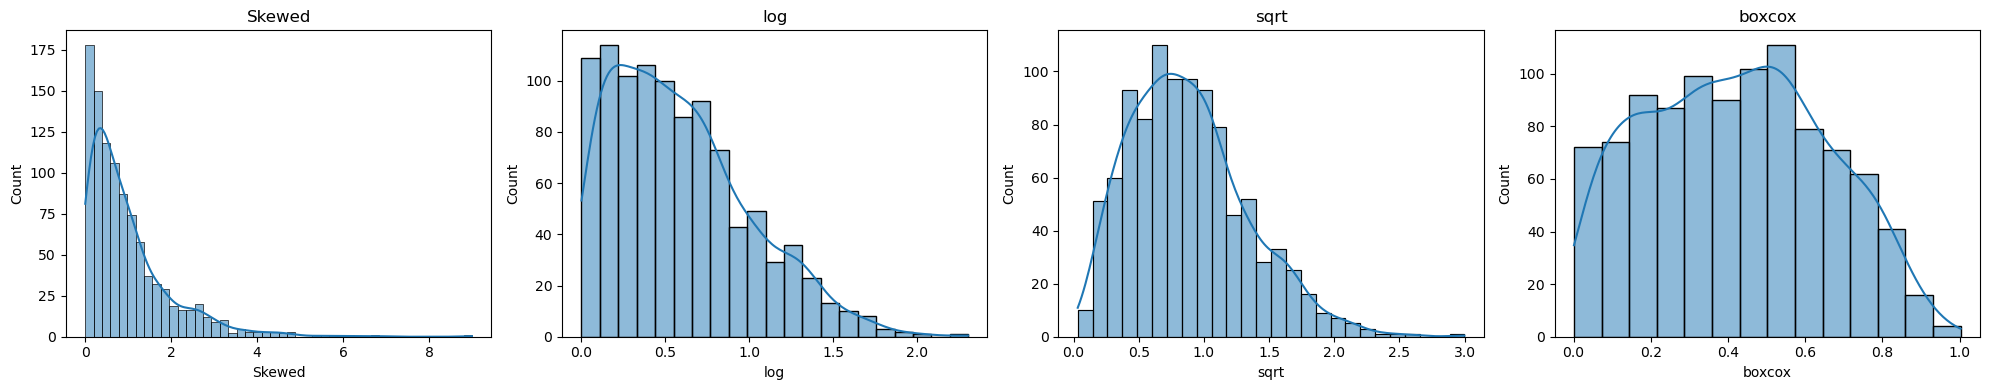

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import boxcox
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.DataFrame({'Skewed': np.random.exponential(size=1000)})

data['log'] = np.log1p(data['Skewed'])

data['sqrt'] = np.sqrt(data['Skewed'])

data['boxcox'], _ = boxcox(data['Skewed'] + 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(data.columns):
    sns.histplot(data[col], ax=axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [3]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

df = pd.DataFrame({'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']})

le = LabelEncoder()
df['Color_Encoded'] = le.fit_transform(df['Color'])

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['Color']])
onehot_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['Color']))

df_combined = pd.concat([df, onehot_df], axis=1)
print(df_combined)

   Color  Color_Encoded  Color_Blue  Color_Green  Color_Red
0    Red              2         0.0          0.0        1.0
1  Green              1         0.0          1.0        0.0
2   Blue              0         1.0          0.0        0.0
3  Green              1         0.0          1.0        0.0
4    Red              2         0.0          0.0        1.0


In [4]:
import pandas as pd
from sklearn.preprocessing import Binarizer

df = pd.read_csv('diabetes.csv')

binarizer = Binarizer(threshold=0.5)
df['Glucose_Binarized'] = binarizer.fit_transform(df[['Glucose']])
print(df[['Glucose', 'Glucose_Binarized']].head())

   Glucose  Glucose_Binarized
0      148                  1
1       85                  1
2      183                  1
3       89                  1
4      137                  1


In [5]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

scaler = MinMaxScaler()
normalized = scaler.fit_transform(iris_df)
normalized_df = pd.DataFrame(normalized, columns=iris.feature_names)
print(normalized_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.625000           0.067797          0.041667
1           0.166667          0.416667           0.067797          0.041667
2           0.111111          0.500000           0.050847          0.041667
3           0.083333          0.458333           0.084746          0.041667
4           0.194444          0.666667           0.067797          0.041667


In [6]:
import pandas as pd
from sklearn.preprocessing import Normalizer

df = pd.read_csv('diabetes.csv')
array = df.drop('Outcome', axis=1).values  # Remove target column if needed

l1 = Normalizer(norm='l1')
l1_normalized = l1.fit_transform(array)

l2 = Normalizer(norm='l2')
l2_normalized = l2.fit_transform(array)

print("L1 Normalized (first row):", l1_normalized[0])
print("L2 Normalized (first row):", l2_normalized[0])

L1 Normalized (first row): [0.01737987 0.42870343 0.20855843 0.10138257 0.         0.09732727
 0.0018162  0.14483224]
L2 Normalized (first row): [0.03355237 0.82762513 0.40262844 0.19572216 0.         0.18789327
 0.00350622 0.27960308]


In [13]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'A': [1, 2, np.nan, 4, 5],
    'B': [np.nan, 2, 3, 4, 5]
})

df['A_mean'] = df['A'].fillna(df['A'].mean())
df['B_mean'] = df['B'].fillna(df['B'].mean())

for i in range(len(df)):
    if pd.isna(df.loc[i, 'A']):
        df.loc[i, 'A'] = df.loc[i, 'A_mean']

for i in range(len(df)):
    if pd.isna(df.loc[i, 'B']):
        df.loc[i, 'B'] = df.loc[i, 'B_mean']

print(df)

     A    B  A_mean  B_mean
0  1.0  3.5     1.0     3.5
1  2.0  2.0     2.0     2.0
2  3.0  3.0     3.0     3.0
3  4.0  4.0     4.0     4.0
4  5.0  5.0     5.0     5.0
